# C — Classification — statut de réservation (EventZilla)

**Cible** : `reservation_status` (classes DW). **X** : jusqu’à 20 numériques du jeu large. **Split** : 75/25 **stratifié** ; **GridSearchCV** 5-fold **stratifié** sur le train.

Le problème est **supervisé** : on apprend une règle qui associe des signaux financiers / calendrier à un **statut de réservation** (funnel). Le split stratifié garantit que chaque classe garde une proportion **représentative** dans le train et le test, ce qui est crucial quand certaines modalités sont rares.

**≥ 2 modèles** : **Random Forest** (non-linéaire, `class_weight='balanced'`) vs **régression logistique multinomiale** (baseline interprétable, même pondération).

**Grille C** : Accuracy, Precision, Recall, **F1** (pondéré), **ROC-AUC** ; matrice de confusion ; ROC si **binaire** ; importances (RF).

**B** : RF — arbres, pas de linéarité ; LR — log-odds linéaires après scaling ; les deux sensibles au **déséquilibre** (d’où `balanced`). Développement du critère **B** : **`06_B_comprehension_modeles.ipynb`**.

Références : dashboards EventZilla.


## Référence C

Pipeline `StandardScaler → estimateur`, **GridSearchCV**, **StratifiedKFold**, métriques sur **test** après tuning sur train.

**Pourquoi ce protocole** : le **GridSearch** et la **CV** n’utilisent **que le train** pour choisir les hyperparamètres ; le **test** reste une **estimation honnête** de la généralisation. Sans cette séparation, optimiser sur tout le jeu gonflerait artificiellement les scores. Le **F1 pondéré** en scoring CV pénalise un peu plus les erreurs sur les classes **peu nombreuses** qu’un simple accuracy.


## 1. Connexion DW

Diagnostic serveur / base / `DB_NAME()` — aligné SSMS.


In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "ML" / "ml_paths.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "ML" / "ml_paths.py").is_file():
    raise FileNotFoundError("Ouvrez Jupyter depuis la racine du dépôt (dossier contenant ML/)")
sys.path.insert(0, str(REPO_ROOT))

print("--- Interprétation (connexion) ---")
print(
    "La racine du dépôt est résolue pour que les imports « from ML.... » fonctionnent "
    "même si le carnet n'est pas lancé depuis la racine."
)
print(
    "Le test SQL DB_NAME() ci-dessous vérifie que la session Python pointe sur la même base DW "
    "que sous SSMS ; sinon les extractions ML ne seraient pas alignées avec Power BI / le critère A."
)
print()

from ML.ml_paths import (
    DATABASE_DW,
    SQL_SERVER,
    SQL_DRIVER,
    SQL_PORT,
    build_windows_auth_uri,
    get_sql_engine,
    ml_sql_only,
    read_dw_sql,
    sql_engine_init_error,
)

print("=" * 62)
print(" EVENTZILLA — Connexion DW (équivalent accès SSMS)")
print("=" * 62)
print("  Serveur SQL      :", SQL_SERVER + (":" + str(SQL_PORT) if SQL_PORT else ""))
print("  Base DW cible    :", DATABASE_DW)
print("  Driver ODBC      :", SQL_DRIVER)
print("  Mode DW seul     :", ml_sql_only(), "(EVENTZILLA_ML_SQL_ONLY=1 → pas de Excel/CSV)")
try:
    _uri = build_windows_auth_uri()
    print("  Chaîne (extrait) :", (_uri[:88] + "…") if len(_uri) > 88 else _uri)
except Exception as _uerr:
    print("  Chaîne URI       : erreur", _uerr)
_eng = get_sql_engine()
if _eng is not None:
    try:
        _chk = read_dw_sql(
            "SELECT DB_NAME() AS base_active, CAST(SERVERPROPERTY('ServerName') AS NVARCHAR(128)) AS serveur",
            _eng,
        )
        print("  Test SQL         : OK — même base que sous SSMS si base_active =", DATABASE_DW)
        print(_chk.to_string(index=False))
    except Exception as _qerr:
        print("  Test SQL         : ÉCHEC —", _qerr)
else:
    print("  Engine           : ABSENT —", sql_engine_init_error() or "voir pip sqlalchemy pyodbc")
print("=" * 62)


--- Interprétation (connexion) ---
La racine du dépôt est résolue pour que les imports « from ML.... » fonctionnent même si le carnet n'est pas lancé depuis la racine.
Le test SQL DB_NAME() ci-dessous vérifie que la session Python pointe sur la même base DW que sous SSMS ; sinon les extractions ML ne seraient pas alignées avec Power BI / le critère A.

 EVENTZILLA — Connexion DW (équivalent accès SSMS)
  Serveur SQL      : ASUSRANIM
  Base DW cible    : DW_eventzella
  Driver ODBC      : ODBC Driver 17 for SQL Server
  Mode DW seul     : True (EVENTZILLA_ML_SQL_ONLY=1 → pas de Excel/CSV)
  Chaîne (extrait) : mssql+pyodbc://@ASUSRANIM/DW_eventzella?driver=ODBC+Driver+17+for+SQL+Server&trusted_con…
  Test SQL         : OK — même base que sous SSMS si base_active = DW_eventzella
  base_active   serveur
DW_eventzella AsusRanim


### Après connexion

Vérifier base active = DW attendue pour reproduire les extractions classification.

Une base incorrecte peut tout de même « fonctionner » techniquement mais produire un **autre schéma** ou des jointures vides : si les dimensions du dataframe ou la colonne statut ne correspondent pas à l’attendu, revenez à cette étape avant d’interpréter les métriques.


### Figures

`plt.show()` inline. Exécuter le flux dans l’ordre.

Les graphiques (matrice de confusion, ROC, importances) ne sont pas décoratifs : ils traduisent **où** le modèle se trompe (confusions entre statuts proches dans le funnel) et **quels** signaux dominent la décision côté forêt aléatoire.


## 2. Imports

Libs sklearn + dossier `ML/models/`. `ML_SQL_ONLY` affiché.

Les imports fixent le **contrat** du notebook : mêmes métriques, mêmes pipelines, mêmes chemins d’export (`ML_PROCESSED`, `ML_MODELS`) que le reste de la chaîne EventZilla. En cas d’erreur d’import, vérifiez que Jupyter est lancé depuis la **racine du dépôt** (dossier contenant `ML/`).


In [2]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "ML" / "ml_paths.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "ML" / "ml_paths.py").is_file():
    raise FileNotFoundError("Ouvrez Jupyter depuis la racine du dépôt (dossier contenant ML/)")
sys.path.insert(0, str(REPO_ROOT))

%matplotlib inline
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from ML.csv_local_fallback import (
    enrich_financial_wide_with_performance_reservation_status,
    financial_wide_has_status_column,
    load_reservation_dataframe,
    resolve_classification_status_column,
)
from ML.ml_paths import ML_PROCESSED, ML_MODELS, ensure_processed_dirs, get_sql_engine, ml_sql_only, read_dw_sql
from ML.schema_eventzilla import SQL_ML_FINANCIAL_WIDE, build_sql_ml_financial_wide

warnings.filterwarnings("ignore")
ensure_processed_dirs()
ML_MODELS.mkdir(parents=True, exist_ok=True)

print("--- Interprétation (imports) ---")
print(
    "Prochaines étapes : split train/test stratifié, puis GridSearchCV avec scoring « f1_weighted » "
    "(adapté aux classes déséquilibrées) et validation croisée stratifiée sur le jeu d'entraînement seul."
)
print("Le jeu test sert uniquement à l'évaluation finale (pas au choix des hyperparamètres).")
print()
print("[1] Classification critère C — RF vs LogisticRegression. ML_SQL_ONLY:", ml_sql_only())


--- Interprétation (imports) ---
Prochaines étapes : split train/test stratifié, puis GridSearchCV avec scoring « f1_weighted » (adapté aux classes déséquilibrées) et validation croisée stratifiée sur le jeu d'entraînement seul.
Le jeu test sert uniquement à l'évaluation finale (pas au choix des hyperparamètres).

[1] Classification critère C — RF vs LogisticRegression. ML_SQL_ONLY: True


### Après imports

Prêt pour chargement des données et pipelines C.

À ce stade, les **grilles** d’hyperparamètres et le **scoring** `f1_weighted` sont déjà définis dans le code suivant : gardez en tête que la comparaison RF vs LR reste **équitable** (même scaler, même CV, même pondération `balanced`).


## 3. Chargement des données

Parquet / SQL : présence colonne **statut** obligatoire pour la suite.

**Contrôle** : sortie `[2]` = dimensions + source.

Le code privilégie le **parquet** issu de **00_A** puis retombe sur le DW si besoin ; l’enrichissement via `Fact_Performance` / `DimReservation` vise à **rétablir** la colonne statut lorsque la vue wide seule ne l’expose pas. Notez bien la **source** affichée : un run « local » hors DW n’est pas équivalent à un run **SQL_ONLY** pour la traçabilité du rapport.


In [3]:
print("--- Interprétation (chargement des données) ---")
print(
    "Ordre de repli : parquet « wide » local si présent ; sinon requête SQL équivalente ; "
    "enrichissement via Fact_Performance + DimReservation si la colonne statut manque."
)
print("Variable d'environnement : ML_SQL_ONLY=1 interdit le repli CSV local (traçabilité DW).")
print()

pp = ML_PROCESSED / "dw_financial_wide.parquet"
df = None
if pp.is_file():
    df = pd.read_parquet(pp)
    print("[2] Source : dw_financial_wide.parquet")
    if not financial_wide_has_status_column(df):
        eng = get_sql_engine()
        if eng is not None:
            try:
                q_fin = build_sql_ml_financial_wide(eng)
                df_dw = read_dw_sql(q_fin, eng)
                if financial_wide_has_status_column(df_dw):
                    df = df_dw
                    print("[2] Parquet sans statut — rechargement DW avec jointure DimReservation (``r.status`` → reservation_status).")
                else:
                    print("[2] Avertissement : requête rentabilité sans statut — essai pont Fact_Performance.")
            except Exception as e:
                print("[2] Rechargement DW pour ajouter le statut : échec —", e)
else:
    eng = get_sql_engine()
    if eng is None:
        if ml_sql_only():
            raise RuntimeError("[2] Pas de parquet DW et pas de SQL (EVENTZILLA_ML_SQL_ONLY=1). Exécuter le critère A ou vérifier la connexion SSMS.")
        df = load_reservation_dataframe()
        print("[2] Source : Reservation (local, ML_SQL_ONLY=0)")
    else:
        try:
            q_fin = build_sql_ml_financial_wide(eng)
            df = read_dw_sql(q_fin, eng)
            print("[2] Source : SQL DW (requête adaptée, jointures *_SK)")
        except Exception as e:
            print("[2] SQL dynamique indisponible, essai statique :", e)
            try:
                df = read_dw_sql(SQL_ML_FINANCIAL_WIDE, eng)
                print("[2] Source : SQL DW (statique)")
            except Exception as e2:
                if ml_sql_only():
                    raise RuntimeError("[2] DW inaccessible (dynamique + statique) : " + str(e2)) from e2
                print("[2] SQL statique échoué, local :", e2)
                df = load_reservation_dataframe()
if df is None:
    raise RuntimeError("[2] Aucun DataFrame chargé.")
if not financial_wide_has_status_column(df):
    _eng = get_sql_engine()
    if _eng is not None:
        df_try = enrich_financial_wide_with_performance_reservation_status(df, _eng)
        if financial_wide_has_status_column(df_try):
            df = df_try
            print("[2] Pont Fact_Performance + DimReservation : ``reservation_status`` fusionné sur (id_date, id_event).")
print("[2] Dimensions :", df.shape)


--- Interprétation (chargement des données) ---
Ordre de repli : parquet « wide » local si présent ; sinon requête SQL équivalente ; enrichissement via Fact_Performance + DimReservation si la colonne statut manque.
Variable d'environnement : ML_SQL_ONLY=1 interdit le repli CSV local (traçabilité DW).

[2] Source : dw_financial_wide.parquet
[2] Avertissement : requête rentabilité sans statut — essai pont Fact_Performance.
[2] Pont Fact_Performance + DimReservation : ``reservation_status`` fusionné sur (id_date, id_event).
[2] Dimensions : (20142, 17)


### Après chargement

Sans statut exploitable → arrêt logique du workflow classification.

Si les dimensions sont très faibles après filtrage, le problème est souvent **amont** (jointure réservation, qualité des clés date/événement). Corriger le DW ou le parquet est préférable à « forcer » un modèle sur trop peu de lignes.


## 4. Cible, X, split stratifié

**Stratifié** : mêmes proportions de classes en train / test.

**Sortie `[3]`** : liste features, nombre de classes, tailles train/test.

La limite à **20** features numériques est un compromis **pédagogique / stabilité** sur le jeu wide : en production on pourrait élargir, mais il faut alors surveiller le temps de calcul et le risque de **multicolinéarité** (surtout pour la régression logistique). L’imputation médiane sur `X` ici est **locale** au notebook de classification (complément du pipeline **00_A** pour les colonnes retenues).


In [4]:
print("--- Interprétation (cible, X, split) ---")
print("La colonne statut est résolue automatiquement parmi les noms possibles du DW.")
print("Les lignes sans statut réservation sont exclues (pas de classe artificielle « missing » apprise).")
print("Les features sont numériques (max 20) ; les NaN sont remplacés par la médiane (robuste aux extrêmes).")
print("Le split 75/25 est stratifié : même proportion de chaque statut dans train et test (si plusieurs classes).")
print()

status_col = resolve_classification_status_column(df)
sc = df[status_col]
has_status = sc.notna()
n_miss = int((~has_status).sum())
if n_miss:
    print("[3] Lignes sans statut exclues :", n_miss, "(pas d'entraînement sur une classe « missing » artificielle).")
df = df.loc[has_status].reset_index(drop=True)
if len(df) < 20:
    raise ValueError(
        f"Trop peu de lignes avec statut renseigné ({len(df)}). Vérifiez les jointures réservation dans le DW."
    )
y_raw = df[status_col].astype(str)
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "fact_finance_id"][:20]
X_df = df[num_cols].fillna(df[num_cols].median(numeric_only=True))
print("[3] Cible :", status_col, "| Classes :", y_raw.nunique())
print("[3] Features numériques (max 20) :", list(X_df.columns))

le = LabelEncoder()
y = le.fit_transform(y_raw)
strat = y if len(set(y)) > 1 else None
Xtr, Xte, ytr, yte = train_test_split(
    X_df.values, y, test_size=0.25, random_state=42, stratify=strat
)
print("[3] Train / test :", Xtr.shape[0], "/", Xte.shape[0])


--- Interprétation (cible, X, split) ---
La colonne statut est résolue automatiquement parmi les noms possibles du DW.
Les lignes sans statut réservation sont exclues (pas de classe artificielle « missing » apprise).
Les features sont numériques (max 20) ; les NaN sont remplacés par la médiane (robuste aux extrêmes).
Le split 75/25 est stratifié : même proportion de chaque statut dans train et test (si plusieurs classes).

[3] Lignes sans statut exclues : 17643 (pas d'entraînement sur une classe « missing » artificielle).
[3] Cible : reservation_status | Classes : 3
[3] Features numériques (max 20) : ['id_date', 'id_event', 'id_servicecategory', 'id_benchmark', 'id_provider', 'final_price', 'service_price', 'benchmark_avg_price', 'event_budget', 'cal_month', 'cal_year', 'quarter']
[3] Train / test : 1874 / 625


### Après split

Nombre de classes et de features fixe la **complexité** (multiclasse, ROC conditionnelle).

Un grand nombre de classes avec des effectifs très **déséquilibrés** explique souvent un accuracy « moyen » mais un **rappel** faible sur les statuts rares : c’est normal — lisez surtout le **rapport par classe** et la matrice de confusion plutôt qu’un seul chiffre global.


## 5. Entraînement (GridSearch)

**RF** : grille `n_estimators`, `max_depth` — score CV **F1 pondéré**.

**LR** : grille sur `C` — même protocole.

**Après code** : comparer `best_params_` ; préparer comparaison **test**.

Si le meilleur `max_depth` est `None` pour la RF, le modèle autorise des arbres **plus profonds** : surveillez l’écart train/test dans le rapport (risque de sur-apprentissage). Pour la LR, un **C** plus petit correspond à **plus** de régularisation — utile si les features sont redondantes.


### Modèle 1 — Random Forest

GridSearch 5-fold stratifié, F1 pondéré sur **train uniquement**.

La forêt capture des **seuils** et interactions entre variables sans les coder à la main ; les **importances** (après entraînement) aident à prioriser les investigations métier, en gardant à l’esprit qu’elles mesurent la **contribution au modèle**, pas une causalité expérimentale.


In [5]:
print("=" * 62)
print(" Random Forest — validation croisée + GridSearchCV (sur le TRAIN uniquement)")
print("=" * 62)
print("StratifiedKFold(5) : chaque pli garde la proportion des statuts (comme le train/test).")
print("GridSearchCV teste toutes les combinaisons de la grille ; le score moyen par config = moyenne des 5 folds.")
print("Scoring : f1_weighted = F1 par classe pondéré par l'effectif (cohérent avec classes déséquilibrées).")
print("Le jeu test (Xte) n'est jamais utilisé pour choisir les hyperparamètres (évite l'optimisme artificiel).")
print()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe_rf = Pipeline([
    ("scale", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=42, class_weight="balanced")),
])
grid_rf = {
    "clf__n_estimators": [80, 120],
    "clf__max_depth": [None, 12],
}
print("Grille RF : n_estimators = nombre d'arbres (variance souvent plus basse si plus grand) ;")
print("            max_depth = limite de profondeur (None = pas de limite ; valeur fixe limite le sur-apprentissage).")
print("Combinaisons à évaluer :", len(grid_rf["clf__n_estimators"]) * len(grid_rf["clf__max_depth"]))
print()

gs_rf = GridSearchCV(pipe_rf, grid_rf, cv=cv, scoring="f1_weighted", n_jobs=-1)
gs_rf.fit(Xtr, ytr)

print()
print("--- Résultat GridSearch RF ---")
print("Meilleurs hyperparamètres (maximisent le F1 pondéré moyen en CV) :", gs_rf.best_params_)
print("Meilleur score CV (moyenne sur les 5 folds) :", round(float(gs_rf.best_score_), 6))
print("Puis ré-entraînement sur tout le train avec ces paramètres -> best_estimator_.")
print()

best_rf = gs_rf.best_estimator_
pred_rf = best_rf.predict(Xte)
proba_rf = best_rf.predict_proba(Xte)
print("Évaluation sur le jeu TEST (généralisation) : prédictions et probabilités calculées.")


 Random Forest — validation croisée + GridSearchCV (sur le TRAIN uniquement)
StratifiedKFold(5) : chaque pli garde la proportion des statuts (comme le train/test).
GridSearchCV teste toutes les combinaisons de la grille ; le score moyen par config = moyenne des 5 folds.
Scoring : f1_weighted = F1 par classe pondéré par l'effectif (cohérent avec classes déséquilibrées).
Le jeu test (Xte) n'est jamais utilisé pour choisir les hyperparamètres (évite l'optimisme artificiel).

Grille RF : n_estimators = nombre d'arbres (variance souvent plus basse si plus grand) ;
            max_depth = limite de profondeur (None = pas de limite ; valeur fixe limite le sur-apprentissage).
Combinaisons à évaluer : 4


--- Résultat GridSearch RF ---
Meilleurs hyperparamètres (maximisent le F1 pondéré moyen en CV) : {'clf__max_depth': None, 'clf__n_estimators': 80}
Meilleur score CV (moyenne sur les 5 folds) : 0.339375
Puis ré-entraînement sur tout le train avec ces paramètres -> best_estimator_.

Évaluation 

### Modèle 2 — Régression logistique

Même validation ; baseline **linéaire** en probabilités.

Les **coefficients** (après `StandardScaler`) se lisent comme « effet marginal » sur les **log-odds** : pratique pour expliquer le funnel à un public non expert en arbres. En multiclasse, chaque classe a son jeu de coefficients ; comparez-les aux importances RF pour voir si la **structure** du problème est plutôt linéaire ou à frontières courbes.


In [6]:
print("=" * 62)
print(" Régression logistique — même protocole CV / GridSearch que la RF")
print("=" * 62)
print("StandardScaler est nécessaire : les coefficients LR sont interprétables en échelles comparables.")
print("Hyperparamètre C : inverse de la régularisation L2 — petit C = modèle plus simple (moins de sur-apprentissage possible).")
print()

pipe_lr = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(random_state=42, max_iter=3000, class_weight="balanced")),
])
grid_lr = {"clf__C": [0.1, 1.0, 10.0]}
print("Grille LR : C in", grid_lr["clf__C"])
print("Combinaisons :", len(grid_lr["clf__C"]))
print()

gs_lr = GridSearchCV(pipe_lr, grid_lr, cv=cv, scoring="f1_weighted", n_jobs=-1)
gs_lr.fit(Xtr, ytr)

print()
print("--- Résultat GridSearch LR ---")
print("Meilleurs hyperparamètres :", gs_lr.best_params_)
print("Meilleur score CV (moyenne sur les 5 folds) :", round(float(gs_lr.best_score_), 6))
print()

best_lr = gs_lr.best_estimator_
pred_lr = best_lr.predict(Xte)
proba_lr = best_lr.predict_proba(Xte)
print("Évaluation sur le jeu TEST : prédictions et probabilités pour comparaison avec la RF.")


 Régression logistique — même protocole CV / GridSearch que la RF
StandardScaler est nécessaire : les coefficients LR sont interprétables en échelles comparables.
Hyperparamètre C : inverse de la régularisation L2 — petit C = modèle plus simple (moins de sur-apprentissage possible).

Grille LR : C in [0.1, 1.0, 10.0]
Combinaisons : 3


--- Résultat GridSearch LR ---
Meilleurs hyperparamètres : {'clf__C': 0.1}
Meilleur score CV (moyenne sur les 5 folds) : 0.348932

Évaluation sur le jeu TEST : prédictions et probabilités pour comparaison avec la RF.


## 6. Comparaison test & figures

**Champion** : meilleur **F1 pondéré** sur test (ajuster si politique métier différente).

**Interprétation** :

| Viz | Lecture |
|-----|---------|
| **Matrice de confusion** | Quelles classes sont confondues ? |
| **ROC + AUC** | Séparation des scores (si binaire) ; sinon AUC multiclasse / one-vs-rest selon code |
| **Importances RF** | Variables qui **orientent** le plus les coupures (pas causalité) |

**Synthèse** : un bon modèle métier n’est pas seulement celui qui maximise une métrique : il doit avoir des erreurs **explicables** (confusions entre statuts « proches » dans le processus) et des scores **calibrés** pour un usage opérationnel (priorisation des dossiers).



 Comparaison RF vs LR sur le jeu TEST
Les tableaux ci-dessous comparent la performance hors échantillon (données non vues à l'entraînement).

--- Métriques sur le jeu TEST ( RandomForest (GridSearch) ) — généralisation, pas le score CV ---
=== RandomForest (GridSearch) (test) ===
 Accuracy: 0.336 | Precision w: 0.3351 | Recall w: 0.336 | F1 w: 0.3351 | ROC-AUC: 0.5084
 (weighted = moyenne pondérée par l'effectif de chaque classe, alignée sur f1_weighted en CV)
              precision    recall  f1-score   support

   cancelled       0.36      0.38      0.37       210
   confirmed       0.33      0.34      0.33       207
     pending       0.32      0.29      0.30       208

    accuracy                           0.34       625
   macro avg       0.33      0.34      0.34       625
weighted avg       0.34      0.34      0.34       625


--- Métriques sur le jeu TEST ( LogisticRegression (GridSearch) ) — généralisation, pas le score CV ---
=== LogisticRegression (GridSearch) (test) ===
 

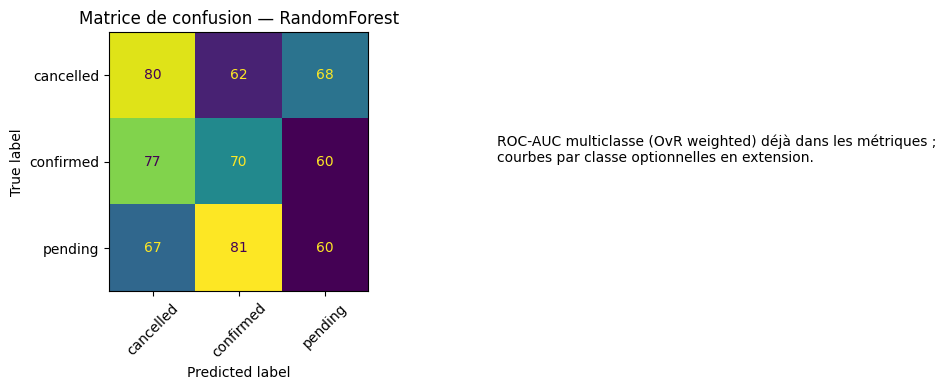


--- Importances des variables (RF champion) ---
Valeur = contribution au gain d'impureté agrégée sur les arbres (ordre relatif utile ; ce n'est pas une causalité métier).


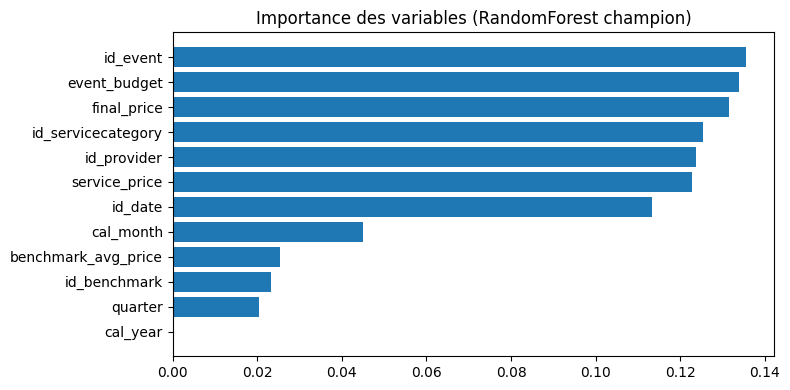

In [7]:
class_labels = [str(c) for c in le.classes_]


def report_block(name, pred, proba):
    print()
    print("--- Métriques sur le jeu TEST (", name, ") — généralisation, pas le score CV ---")
    acc = accuracy_score(yte, pred)
    pr_w = precision_score(yte, pred, average="weighted", zero_division=0)
    rc_w = recall_score(yte, pred, average="weighted", zero_division=0)
    f1w = f1_score(yte, pred, average="weighted", zero_division=0)
    if len(le.classes_) > 2:
        auc = roc_auc_score(yte, proba, multi_class="ovr", average="weighted")
    else:
        auc = roc_auc_score(yte, proba[:, 1])
    print(f"=== {name} (test) ===")
    print(" Accuracy:", round(acc, 4), "| Precision w:", round(pr_w, 4), "| Recall w:", round(rc_w, 4), "| F1 w:", round(f1w, 4), "| ROC-AUC:", round(auc, 4))
    print(" (weighted = moyenne pondérée par l'effectif de chaque classe, alignée sur f1_weighted en CV)")
    print(classification_report(yte, pred, target_names=class_labels, zero_division=0))
    return {"acc": acc, "pr": pr_w, "rc": rc_w, "f1": f1w, "auc": auc}


print()
print("=" * 62)
print(" Comparaison RF vs LR sur le jeu TEST")
print("=" * 62)
print("Les tableaux ci-dessous comparent la performance hors échantillon (données non vues à l'entraînement).")

m_rf = report_block("RandomForest (GridSearch)", pred_rf, proba_rf)
m_lr = report_block("LogisticRegression (GridSearch)", pred_lr, proba_lr)

print()
print("--- Choix du modèle champion ---")
print("On retient le modèle avec le meilleur F1 pondéré sur le TEST (même esprit que le scoring en CV).")
if m_rf["f1"] >= m_lr["f1"]:
    champion, champ_name = best_rf, "RandomForest"
    pred_ch, proba_ch = pred_rf, proba_rf
else:
    champion, champ_name = best_lr, "LogisticRegression"
    pred_ch, proba_ch = pred_lr, proba_lr
print("[4] Champion (F1 pondéré test) :", champ_name)

print()
print("--- Figures ---")
print("Matrice de confusion : lignes = vrai statut, colonnes = statut prédit (erreurs hors diagonale).")
if len(le.classes_) == 2:
    print("Courbe ROC : applicable en classification binaire (probabilité de la classe positive).")
else:
    print("ROC : vue synthétique multiclasse = métrique OvR weighted dans les scores ; courbes par classe possibles en extension.")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(yte, pred_ch, display_labels=class_labels, ax=ax[0], xticks_rotation=45, colorbar=False)
ax[0].set_title("Matrice de confusion — " + champ_name)
if len(le.classes_) == 2:
    RocCurveDisplay.from_predictions(yte, proba_ch[:, 1], ax=ax[1])
    ax[1].set_title("ROC — " + champ_name)
else:
    ax[1].axis("off")
    ax[1].text(0.1, 0.5, "ROC-AUC multiclasse (OvR weighted) déjà dans les métriques ;\ncourbes par classe optionnelles en extension.", fontsize=10)
plt.tight_layout()
plt.show()

if champ_name == "RandomForest":
    print()
    print("--- Importances des variables (RF champion) ---")
    print("Valeur = contribution au gain d'impureté agrégée sur les arbres (ordre relatif utile ; ce n'est pas une causalité métier).")
    imp = champion.named_steps["clf"].feature_importances_
    order = np.argsort(imp)[::-1][:15]
    plt.figure(figsize=(8, 4))
    plt.barh(np.array(X_df.columns)[order][::-1], imp[order][::-1])
    plt.title("Importance des variables (RandomForest champion)")
    plt.tight_layout()
    plt.show()

acc = float(accuracy_score(yte, pred_ch))
f1 = float(f1_score(yte, pred_ch, average="weighted", zero_division=0))
prec = float(precision_score(yte, pred_ch, average="weighted", zero_division=0))
rec = float(recall_score(yte, pred_ch, average="weighted", zero_division=0))
if len(le.classes_) > 2:
    roc_auc = float(roc_auc_score(yte, proba_ch, multi_class="ovr", average="weighted"))
else:
    roc_auc = float(roc_auc_score(yte, proba_ch[:, 1]))


### Après métriques

GridSearch → hyperparamètres optimaux sur CV. **Test** : écart RF vs LR ; confusion = **erreurs** par paire de statuts ; ROC = capacité de **ranking** des scores ; importances = **pistes métier** pour les drivers du statut.

Si les deux modèles sont **proches** sur le test, privilégiez souvent la **LR** pour l’explicabilité ou la **RF** si les gains sur les classes difficiles le justifient — documentez ce choix dans le rapport (politique de **rappel** vs **précision** selon le coût métier des faux positifs/négatifs).



In [8]:
print("--- Interprétation (sauvegarde) ---")
print("On enregistre le pipeline complet (scaler + modèle) et le LabelEncoder pour appliquer les mêmes étapes en inférence.")
print("Le JSON inclut les best_params_ des deux GridSearch pour traçabilité et comparaison dans le rapport.")
print()

joblib.dump(champion, ML_MODELS / "classification_status_champion_pipeline.joblib")
joblib.dump(le, ML_MODELS / "label_encoder_status.joblib")
if champ_name == "RandomForest":
    joblib.dump(champion, ML_MODELS / "rf_status_kpi_pipeline.joblib")

(ML_MODELS / "metrics_classification.json").write_text(
    json.dumps({
        "task": "classification",
        "criterion": "C",
        "champion_model": champ_name,
        "gridsearch_rf_best_params": gs_rf.best_params_,
        "gridsearch_lr_best_params": gs_lr.best_params_,
        "test_metrics_champion": {
            "accuracy": acc,
            "precision_weighted": prec,
            "recall_weighted": rec,
            "f1_weighted": f1,
            "roc_auc": roc_auc,
        },
        "test_metrics_rf": {
            "accuracy": float(m_rf["acc"]),
            "precision_weighted": float(m_rf["pr"]),
            "recall_weighted": float(m_rf["rc"]),
            "f1_weighted": float(m_rf["f1"]),
            "roc_auc": float(m_rf["auc"]),
        },
        "test_metrics_lr": {
            "accuracy": float(m_lr["acc"]),
            "precision_weighted": float(m_lr["pr"]),
            "recall_weighted": float(m_lr["rc"]),
            "f1_weighted": float(m_lr["f1"]),
            "roc_auc": float(m_lr["auc"]),
        },
        "classes": class_labels,
        "kpi_alignment": "taux_acceptation_annulation_funnel_critere_C",
    }, indent=2),
    encoding="utf-8",
)
print("[5] Pipelines + metrics_classification.json (comparaison 2 modèles + GridSearch).")


--- Interprétation (sauvegarde) ---
On enregistre le pipeline complet (scaler + modèle) et le LabelEncoder pour appliquer les mêmes étapes en inférence.
Le JSON inclut les best_params_ des deux GridSearch pour traçabilité et comparaison dans le rapport.

[5] Pipelines + metrics_classification.json (comparaison 2 modèles + GridSearch).


## 7. Sauvegarde

Pipeline champion + `metrics_classification.json` pour **05** et Streamlit.
